In [2]:
from geno_to_ML1 import *

In [16]:
from sklearn import decomposition
import seaborn as sns
from sklearn.metrics import silhouette_samples,silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [13]:
X = geno_to_ML1('./data/genotypes.csv')

[0.02522262 0.01790478]
[89.85836764 75.70907026]


<Axes: xlabel='PCA1', ylabel='PCA2'>

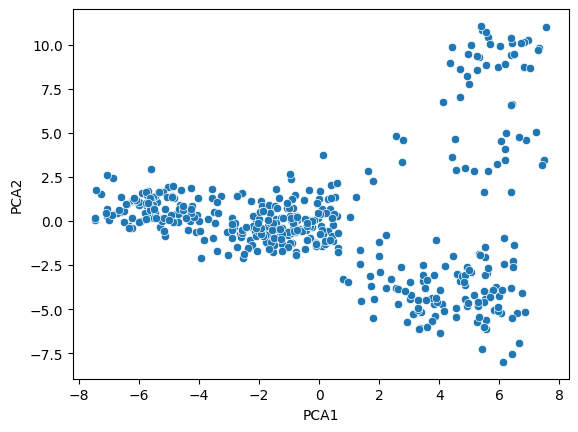

In [14]:
pca = decomposition.PCA(n_components=2)
pca.fit(X)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)
to_plot = pca.transform(X)
to_plot = pd.DataFrame(to_plot, columns = ['PCA1','PCA2'])
sns.scatterplot(x=to_plot.PCA1, y=to_plot.PCA2)


In [15]:
kmeans = KMeans(n_clusters=2, random_state=42)
silhouette_score(X, kmeans.fit_predict(X))

0.028340234256957388

In [33]:
sil = []
kmax = 10

# dissimilarity would not be defined for a single cluster, thus, minimum number of clusters should be 2
for k in range(2, kmax+1):
  kmeans = KMeans(n_clusters = k).fit(X)
  labels = kmeans.labels_
  sil.append(silhouette_score(X, labels, metric = 'euclidean'))

In [40]:
sil

[0.01804617562657525,
 0.022999058194408423,
 -0.00801731677212056,
 0.012371413414387017,
 -0.037098020676761795,
 0.010732730518508588,
 -0.010887793406692449,
 -0.024888788071450858,
 -0.16032499791367635]

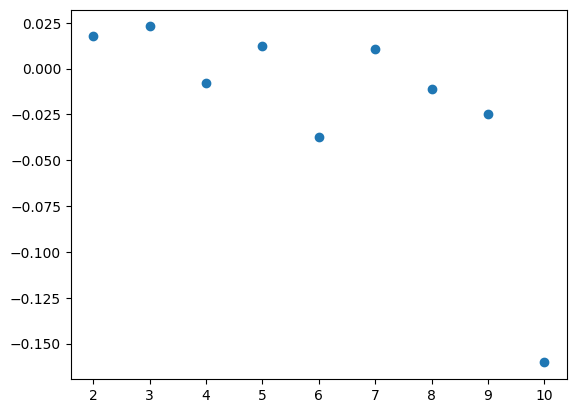

In [39]:
sil_plot = zip(range(2, kmax + 1), sil)
x, y = zip(*sil_plot)
plt.scatter(x, y)